In [1]:
%pip install torch torchvision tqdm matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
transform = transforms.Compose([
      transforms.ToTensor(),
])
# load the CIFAR-100 for train and test
train_dataset = datasets.CIFAR100(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR100(root="./data", train=False, download=True, transform=transform)

100%|██████████| 169M/169M [00:05<00:00, 28.9MB/s] 
/venv/main/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
targets = np.array(train_dataset.targets)
num_classes = 100
labeled_per_class = 10_000 // num_classes

In [6]:
labeled_indices = []
unlabeled_indices = []

for class_idx in range(num_classes):
    class_indices = np.where(targets == class_idx)[0]
    # shuffle class indices for reproducibly
    np.random.shuffle(class_indices)

    # first 100 labeled
    labeled_class_indices = class_indices[:labeled_per_class]
    labeled_indices.extend(labeled_class_indices)
    # remaining 400 unlabeled
    unlabeled_class_indices = class_indices[labeled_per_class:]
    unlabeled_indices.extend(unlabeled_class_indices)

labeled_indices = np.array(labeled_indices)
unlabeled_indices = np.array(unlabeled_indices)

print(f"Labeled Set Size: {len(labeled_indices)}")
print(f"Unlabeled Set Size: {len(unlabeled_indices)}")

Labeled Set Size: 10000
Unlabeled Set Size: 40000


In [7]:
labeled_dataset = Subset(train_dataset, labeled_indices)
unlabeled_dataset = Subset(train_dataset, unlabeled_indices)

In [8]:
batch_size = 130
ratio = len(unlabeled_dataset) // len(labeled_dataset)
batch_size_labeled = batch_size // (ratio + 1)
batch_size_unlabeled = batch_size - batch_size_labeled

print(ratio)
print(f"Labeled Batch Size: {batch_size_labeled}")
print(f"Unlabeled Batch Size: {batch_size_unlabeled}")

4
Labeled Batch Size: 26
Unlabeled Batch Size: 104


In [9]:
labeled_loader = DataLoader(labeled_dataset, batch_size=batch_size_labeled, shuffle=True, num_workers=0)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=batch_size_unlabeled, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Labeled Dataloader Size: {len(labeled_loader)}")
print(f"Unlabeled Dataloader Size: {len(unlabeled_loader)}")

Labeled Dataloader Size: 385
Unlabeled Dataloader Size: 385


In [10]:
class CNN13(nn.Module):
    """
    CNN-13 is a network with 10 convolutional layers follower by 3 linear layers for classification.
    """
    def __init__(
            self, 
            in_channels: int = 3, 
            num_classes: int = 100
        ):
        super().__init__()

        self.features = nn.Sequential(
            # input shape (3, 32, 32)
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), # 3 
            nn.ReLU(inplace=True),

            # input shape (64, 32, 32)
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),  
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 32 -> 16

            # input shape (64, 16, 16)
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False), 
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # input shape (128, 16, 16)
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False), 
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 16 -> 8

            # input shape (128, 8, 8)
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # input shape (256, 8, 8)
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 8 -> 4
        )

        self.classifier = nn.Sequential(
            # input shape (256, 4, 4)
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes)         
        )

    def forward(self, x):
        out = self.features(x)
        out = self.classifier(out)
        return out

In [11]:
@torch.no_grad()
def update_ema_teacher(student: CNN13, teacher: CNN13, ema_decay: float) -> None:
    """
    Updates the parameters of the `teacher` model using using Exponential Moving Average
    and the `student`'s learned parameters.
    """
    student_params = dict(student.named_parameters())
    teacher_params = dict(teacher.named_parameters())
    for name in teacher_params:
        teacher_params[name].data.mul_(ema_decay).add_(student_params[name].data, alpha=1.0 - ema_decay)

    # also update the buffers because running statistics are used to normalize layers
    student_buffers = dict(student.named_buffers())
    teacher_buffers = dict(teacher.named_buffers())
    for name in teacher_buffers:
        teacher_buffers[name].data.copy_(student_buffers[name])


def cons_kl(student_logits, teacher_logits, temperature: float = 1.0):
    """
    Computs the KL-divergence for the given logits for student and teacher models.
    """
    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
    return F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") * (temperature ** 2)


def kl_to_uniform(logits):
    probs = F.softmax(logits, dim=1)
    c = probs.size(1)
    uniform = torch.full_like(probs, 1.0 / c)
    return F.kl_div(probs.clamp_min(1e-8).log(), uniform, reduction="none").sum(dim=1)


def mixup(
        xl: torch.Tensor, 
        yl: torch.Tensor, 
        xu: torch.Tensor, 
        yu_soft: torch.Tensor,
        num_classes: int = 100,    
    ) -> tuple[torch.tensor]:
    """
    Parameters
    ----------
    xl, yl: torch.Tensor, torch.Tensor
        This is the batch of labeled data
    xu, yu_soft: torch.Tensor, torch.Tensor
        This is the batch of unlabeled data and soft labels by the teacher
    """
    Nl, Nu = xl.shape[0], xu.shape[0]

    # oversample the images and labels
    ratio = math.ceil(Nu / Nl)
    # (batch, H, W, 3) ---> (batch * ratio, H, W, 3)
    xl_tiled = xl.repeat((ratio, 1, 1, 1))[:Nu]  
    yl_tiled = yl.repeat(ratio)[:Nu]
    
    # permutate the oversampled data
    perm = torch.randperm(Nu)
    xl_tiled = xl_tiled[perm]
    yl_tiled = yl_tiled[perm]
    yl_tiled_oh = F.one_hot(yl_tiled.long(), num_classes=num_classes).float()

    # generate the mixing parameters for each labeled image
    mu = torch.distributions.Beta(1.0, 1.0).sample((Nu, )).to(xu.device)
    mu_x = mu.view(Nu, 1, 1, 1)
    mu_y = mu.view(Nu, 1)

    xm = mu_x * xu + (1 - mu_x) * xl_tiled
    ym = mu_y * yu_soft + (1 - mu_y) * yl_tiled_oh

    return xm, ym


def train_mean_teacher(
    labeled_loader: DataLoader,
    unlabeled_loader: DataLoader,
    student: CNN13,
    teacher: CNN13,
    optimizer,
    device: torch.device,
    lambda_cons: float = 1.0,
    ema_decay: float = 0.999,
):
    student.train()
    teacher.eval()

    total_loss = 0
    total_sup = 0
    total_cons = 0

    for (xl, yl), (xu, _) in tqdm(zip(labeled_loader, unlabeled_loader)):
        xl, yl = xl.to(device), yl.to(device)
        xu = xu.to(device)

        optimizer.zero_grad()
        
        # compute supervised loss
        student_logits_l = student(xl)
        sup_loss = F.cross_entropy(student_logits_l, yl)

        # compute consistency loss
        student_logits_u = student(xu)
        with torch.no_grad():
            teacher_logits_u = teacher(xu)
        cons_loss = cons_kl(student_logits_u, teacher_logits_u)

        # aggregate the supervised and consistency loss
        loss = sup_loss + lambda_cons * cons_loss
        loss.backward()
        optimizer.step()

        update_ema_teacher(student, teacher, ema_decay)

        total_loss += loss.item()
        total_sup += sup_loss.item()
        total_cons += cons_loss.item()

    return {
        "total_loss": total_loss / len(unlabeled_loader),
        "sup_loss": total_sup / len(unlabeled_loader),
        "cons_loss": total_cons / len(unlabeled_loader),
    }


def train_rlgssl(
    labeled_loader: DataLoader,
    unlabeled_loader: DataLoader,
    student: CNN13,
    teacher: CNN13,
    optimizer,
    device: torch.device,
    lambda_sup: float = 0.1,
    lambda_cons: float = 0.1,
    ema_decay: float = 0.999,
):
    student.train()
    teacher.eval()

    total_loss = 0
    total_rl_loss = 0
    total_sup_loss = 0
    total_cons_loss = 0

    for (xl, yl), (xu, _) in tqdm(zip(labeled_loader, unlabeled_loader)):
        xl, yl = xl.to(device), yl.to(device)
        xu = xu.to(device)
    
        # compute soft-labels for unlabeled data with the teacher
        with torch.no_grad():
            teacher_logits_u = teacher(xu)
            teacher_y_u = F.softmax(teacher_logits_u, dim=1)

        xm, ym = mixup(xl, yl, xu, teacher_y_u)  

        optimizer.zero_grad()
        
        # compute supervised loss 
        student_logits_l = student(xl)
        sup_loss = F.cross_entropy(student_logits_l, yl)

        # compute consistency loss 
        student_logits_u = student(xu)
        with torch.no_grad():
            teacher_logits_u = teacher(xu)
        cons_loss = cons_kl(student_logits_u, teacher_logits_u)

        # compute RL loss
        student_logits_m = student(xm)
        probs_m = F.softmax(student_logits_m, dim=1)

        reward = -F.mse_loss(probs_m, ym, reduction="none").mean(dim=1).detach()
        kl_coeff = kl_to_uniform(student_logits_u)
        rl_loss = -(kl_coeff * reward).mean() 

        # compute total loss
        loss = rl_loss + lambda_sup * sup_loss + lambda_cons * cons_loss
        loss.backward()
        optimizer.step()

        # update the teacher
        update_ema_teacher(student, teacher, ema_decay)

        # save the losses
        total_loss += loss.item()
        total_rl_loss += rl_loss.item()
        total_sup_loss += sup_loss.item()
        total_cons_loss += cons_loss.item()

    return {
        "total_loss": total_loss / len(unlabeled_loader),
        "rl_loss": total_rl_loss / len(unlabeled_loader),
        "sup_loss": total_sup_loss / len(unlabeled_loader),
        "cons_loss": total_cons_loss / len(unlabeled_loader),
    }

In [13]:
def cosine_annealing(epoch, max_epochs, lambda_min=0.0, lambda_max=1.0):
    if max_epochs <= 1:
        return lambda_max
    cos_term = math.cos(math.pi * epoch / (max_epochs - 1))
    return lambda_min + 0.5 * (lambda_max - lambda_min) * (1 - cos_term)

In [14]:
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
student = CNN13().to(device)
teacher = CNN13().to(device)

optimizer = torch.optim.SGD(
    params=student.parameters(),
    lr=0.001,
    momentum=0.9,
    nesterov=True,
    weight_decay=1e-4,
)

total_losses = []
sup_losses = []
cons_losses = []

for epoch in range(epochs):
    lambda_cons = cosine_annealing(epoch, epochs, lambda_min=0.0, lambda_max=1.0)
    losses = train_mean_teacher(labeled_loader, unlabeled_loader, student, teacher, optimizer, device, lambda_cons=lambda_cons)
    
    total_loss = losses["total_loss"]
    sup_loss = losses["sup_loss"]
    cons_loss = losses["cons_loss"]

    if (epoch + 1) % 10 == 0:
        print(f"EPOCH {epoch + 1}: Train Loss: {total_loss:.4f}, Supervision Loss {sup_loss:.4f}, Consistency Loss {cons_loss:.4f}")
        print()

    total_losses.append(total_loss)
    sup_losses.append(sup_loss)
    cons_losses.append(cons_loss)

385it [00:08, 46.87it/s]
385it [00:07, 49.86it/s]
385it [00:07, 49.92it/s]
385it [00:07, 50.56it/s]
385it [00:07, 51.64it/s]
385it [00:07, 50.03it/s]
385it [00:07, 52.09it/s]
385it [00:07, 51.35it/s]
385it [00:07, 53.03it/s]
385it [00:07, 51.81it/s]


EPOCH 10: Train Loss: 2.8198, Supervision Loss 2.7642, Consistency Loss 0.6876



385it [00:07, 50.00it/s]
385it [00:07, 52.20it/s]
385it [00:07, 53.97it/s]
385it [00:07, 50.08it/s]
385it [00:07, 52.41it/s]
385it [00:07, 51.87it/s]
385it [00:07, 51.18it/s]
385it [00:07, 49.55it/s]
385it [00:07, 49.73it/s]
385it [00:07, 49.64it/s]


EPOCH 20: Train Loss: 1.2975, Supervision Loss 1.0668, Consistency Loss 0.7047



385it [00:07, 48.72it/s]
385it [00:07, 48.77it/s]
385it [00:07, 49.28it/s]
385it [00:07, 49.50it/s]
385it [00:07, 49.66it/s]
385it [00:07, 49.50it/s]
385it [00:07, 49.62it/s]
385it [00:07, 54.22it/s]
385it [00:06, 55.43it/s]
385it [00:06, 55.62it/s]


EPOCH 30: Train Loss: 0.4392, Supervision Loss 0.1680, Consistency Loss 0.4223



385it [00:06, 55.23it/s]
385it [00:06, 55.27it/s]
385it [00:07, 53.17it/s]
385it [00:07, 49.25it/s]
385it [00:07, 49.70it/s]
385it [00:07, 53.36it/s]
385it [00:07, 53.12it/s]
385it [00:07, 50.43it/s]
385it [00:07, 49.75it/s]
385it [00:07, 49.88it/s]


EPOCH 40: Train Loss: 0.3506, Supervision Loss 0.0855, Consistency Loss 0.2943



385it [00:07, 49.81it/s]
385it [00:07, 49.82it/s]
385it [00:07, 49.98it/s]
385it [00:07, 49.90it/s]
385it [00:07, 49.57it/s]
385it [00:07, 49.52it/s]
385it [00:07, 49.04it/s]
385it [00:07, 52.05it/s]
385it [00:07, 54.78it/s]
385it [00:07, 54.88it/s]

EPOCH 50: Train Loss: 0.2754, Supervision Loss 0.0518, Consistency Loss 0.2236



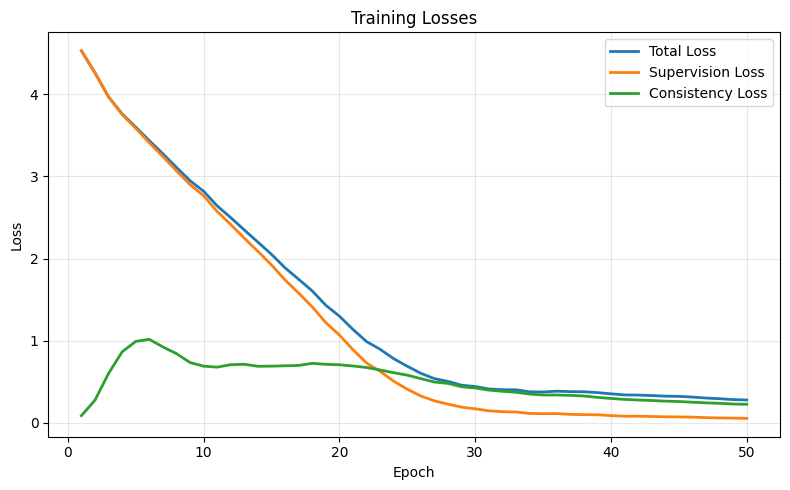

In [15]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, total_losses, label="Total Loss", linewidth=2)
plt.plot(epochs_range, sup_losses, label="Supervision Loss", linewidth=2)
plt.plot(epochs_range, cons_losses, label="Consistency Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
epochs = 200

optimizer = torch.optim.SGD(
    params=student.parameters(),
    lr=0.1,
    momentum=0.9,
    nesterov=True,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs,       
    eta_min=0,
)

total_losses = []
rl_losses = []
sup_losses = []
cons_losses = []

for epoch in range(epochs):
    losses = train_rlgssl(labeled_loader, unlabeled_loader, student, teacher, optimizer, device)
    
    total_loss = losses["total_loss"]
    rl_loss = losses["rl_loss"]
    sup_loss = losses["sup_loss"]
    cons_loss = losses["cons_loss"]
    
    if (epoch + 1) % 10 == 0:
        print(f"EPOCH {epoch + 1}: ---> Train Loss: {total_loss:.4f}, RL Loss: {rl_loss:.4f}, Supervision Loss {sup_loss:.4f}, Consistency Loss {cons_loss:.4f}")
        print()

    total_losses.append(total_loss)
    rl_losses.append(rl_loss)
    sup_losses.append(sup_loss)
    cons_losses.append(cons_loss)

385it [00:08, 47.25it/s]
385it [00:07, 48.13it/s]
385it [00:08, 46.48it/s]
385it [00:08, 43.42it/s]
385it [00:08, 43.27it/s]
385it [00:08, 43.07it/s]
385it [00:08, 43.29it/s]
385it [00:08, 43.29it/s]
385it [00:08, 43.37it/s]
385it [00:08, 43.52it/s]


EPOCH 10: ---> Train Loss: 0.2654, RL Loss: 0.0021, Supervision Loss 2.3228, Consistency Loss 0.3106



385it [00:08, 43.50it/s]
385it [00:08, 43.55it/s]
385it [00:08, 43.75it/s]
385it [00:08, 43.60it/s]
385it [00:08, 43.34it/s]
385it [00:08, 43.31it/s]
385it [00:08, 43.56it/s]
385it [00:08, 44.72it/s]
385it [00:08, 43.67it/s]
385it [00:08, 43.42it/s]


EPOCH 20: ---> Train Loss: 0.1452, RL Loss: 0.0046, Supervision Loss 0.9260, Consistency Loss 0.4801



385it [00:08, 43.43it/s]
385it [00:08, 47.12it/s]
385it [00:08, 46.08it/s]
385it [00:08, 46.50it/s]
385it [00:08, 43.21it/s]
385it [00:08, 42.89it/s]
385it [00:09, 42.47it/s]
385it [00:08, 43.44it/s]
385it [00:08, 43.65it/s]
385it [00:08, 43.68it/s]


...

EPOCH 180: ---> Train Loss: 0.0549, RL Loss: 0.0009, Supervision Loss 0.3328, Consistency Loss 0.2076



385it [00:08, 43.53it/s]
385it [00:08, 44.14it/s]
385it [00:08, 43.22it/s]
385it [00:08, 43.49it/s]
385it [00:08, 43.45it/s]
385it [00:08, 43.93it/s]
385it [00:08, 43.42it/s]
385it [00:08, 43.58it/s]
385it [00:08, 43.60it/s]
385it [00:08, 43.77it/s]


EPOCH 190: ---> Train Loss: 0.0206, RL Loss: 0.0013, Supervision Loss 0.0472, Consistency Loss 0.1459



385it [00:08, 43.72it/s]
385it [00:08, 43.44it/s]
385it [00:08, 43.94it/s]
385it [00:08, 43.84it/s]
385it [00:08, 43.78it/s]
385it [00:08, 44.43it/s]
385it [00:07, 48.65it/s]
385it [00:07, 48.63it/s]
385it [00:07, 48.59it/s]
385it [00:07, 48.63it/s]

EPOCH 200: ---> Train Loss: 0.0365, RL Loss: 0.0004, Supervision Loss 0.2374, Consistency Loss 0.1240



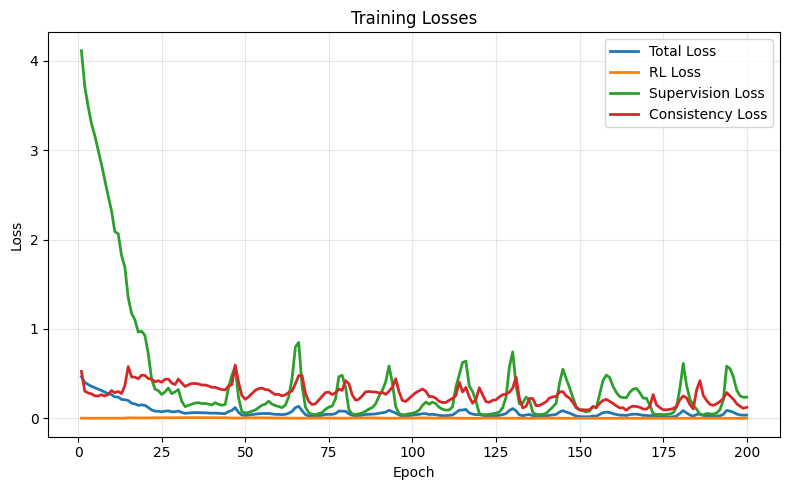

In [17]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, total_losses, label="Total Loss", linewidth=2)
plt.plot(epochs_range, rl_losses, label="RL Loss", linewidth=2)
plt.plot(epochs_range, sup_losses, label="Supervision Loss", linewidth=2)
plt.plot(epochs_range, cons_losses, label="Consistency Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
@torch.no_grad()
def evaluate_test_error(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    accuracy = 100.0 * correct / total
    error = 100.0 - accuracy
    return error, accuracy

In [19]:
test_error, test_acc = evaluate_test_error(student, test_loader, device)
print(f"Test Error: {test_error:.2f}% | Test Accuracy: {test_acc:.2f}%")

Test Error: 83.35% | Test Accuracy: 16.65%


In [20]:
def train_rlgssl_plus(
    labeled_loader: DataLoader,
    unlabeled_loader: DataLoader,
    student: CNN13,
    teacher: CNN13,
    optimizer,
    device: torch.device,
    lambda_sup: float = 0.1,
    lambda_cons: float = 0.1,
    lambda_entropy: float = 0.5,
    ema_decay: float = 0.999,
):
    student.train()
    teacher.eval()

    total_loss = 0
    total_rl_loss = 0
    total_sup_loss = 0
    total_cons_loss = 0

    for (xl, yl), (xu, _) in tqdm(zip(labeled_loader, unlabeled_loader)):
        xl, yl = xl.to(device), yl.to(device)
        xu = xu.to(device)
    
        # compute soft-labels for unlabeled data with the teacher
        with torch.no_grad():
            teacher_logits_u = teacher(xu)
            teacher_y_u = F.softmax(teacher_logits_u, dim=1)

        xm, ym = mixup(xl, yl, xu, teacher_y_u)  

        optimizer.zero_grad()
        
        # compute supervised loss 
        student_logits_l = student(xl)
        sup_loss = F.cross_entropy(student_logits_l, yl)

        # compute consistency loss 
        student_logits_u = student(xu)
        student_probs_u = F.softmax(student_logits_u, dim=1)
        with torch.no_grad():
            teacher_logits_u = teacher(xu)
        cons_loss = cons_kl(student_logits_u, teacher_logits_u)

        # compute RL loss
        student_logits_m = student(xm)
        probs_m = F.softmax(student_logits_m, dim=1)

        reward = -F.mse_loss(probs_m, ym, reduction="none").mean(dim=1).detach()
        entropy = -torch.sum(student_probs_u * torch.log(student_probs_u + 1e-8), dim=1)
        kl_coeff = kl_to_uniform(student_logits_u)
        rl_loss = -((kl_coeff + lambda_entropy * entropy) * reward).mean() 

        # compute total loss
        loss = rl_loss + lambda_sup * sup_loss + lambda_cons * cons_loss
        loss.backward()
        optimizer.step()

        # update the teacher
        update_ema_teacher(student, teacher, ema_decay)

        # save the losses
        total_loss += loss.item()
        total_rl_loss += rl_loss.item()
        total_sup_loss += sup_loss.item()
        total_cons_loss += cons_loss.item()

    return {
        "total_loss": total_loss / len(unlabeled_loader),
        "rl_loss": total_rl_loss / len(unlabeled_loader),
        "sup_loss": total_sup_loss / len(unlabeled_loader),
        "cons_loss": total_cons_loss / len(unlabeled_loader),
    }

In [25]:
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
student = CNN13().to(device)
teacher = CNN13().to(device)

optimizer = torch.optim.SGD(
    params=student.parameters(),
    lr=0.001,
    momentum=0.9,
    nesterov=True,
    weight_decay=1e-4,
)

total_losses = []
sup_losses = []
cons_losses = []

for epoch in range(epochs):
    lambda_cons = cosine_annealing(epoch, epochs, lambda_min=0.0, lambda_max=1.0)
    losses = train_mean_teacher(labeled_loader, unlabeled_loader, student, teacher, optimizer, device, lambda_cons=lambda_cons)
    
    total_loss = losses["total_loss"]
    sup_loss = losses["sup_loss"]
    cons_loss = losses["cons_loss"]

    if (epoch + 1) % 10 == 0:
        print(f"EPOCH {epoch + 1}: Train Loss: {total_loss:.4f}, Supervision Loss {sup_loss:.4f}, Consistency Loss {cons_loss:.4f}")
        print()

    total_losses.append(total_loss)
    sup_losses.append(sup_loss)
    cons_losses.append(cons_loss)

385it [00:07, 49.59it/s]
385it [00:07, 49.60it/s]
385it [00:07, 49.60it/s]
385it [00:07, 49.56it/s]
385it [00:07, 49.55it/s]
385it [00:07, 49.61it/s]
385it [00:07, 49.76it/s]
385it [00:07, 49.59it/s]
385it [00:07, 50.07it/s]
385it [00:07, 49.74it/s]


EPOCH 10: Train Loss: 2.8975, Supervision Loss 2.8434, Consistency Loss 0.6688



385it [00:07, 49.64it/s]
385it [00:07, 49.92it/s]
385it [00:07, 49.78it/s]
385it [00:07, 49.57it/s]
385it [00:07, 49.72it/s]
385it [00:07, 50.06it/s]
385it [00:07, 50.59it/s]
385it [00:07, 50.15it/s]
385it [00:07, 50.27it/s]
385it [00:07, 50.52it/s]


EPOCH 20: Train Loss: 1.3850, Supervision Loss 1.1640, Consistency Loss 0.6751



385it [00:07, 50.40it/s]
385it [00:07, 50.07it/s]
385it [00:07, 49.65it/s]
385it [00:07, 49.78it/s]
385it [00:07, 49.92it/s]
385it [00:06, 55.99it/s]
385it [00:06, 56.68it/s]
385it [00:07, 51.22it/s]
385it [00:07, 50.36it/s]
385it [00:07, 49.93it/s]


EPOCH 30: Train Loss: 0.4619, Supervision Loss 0.1897, Consistency Loss 0.4237



385it [00:07, 49.98it/s]
385it [00:07, 49.79it/s]
385it [00:07, 50.09it/s]
385it [00:07, 50.11it/s]
385it [00:07, 49.98it/s]
385it [00:07, 50.07it/s]
385it [00:07, 50.19it/s]
385it [00:07, 50.17it/s]
385it [00:07, 50.22it/s]
385it [00:07, 51.56it/s]


EPOCH 40: Train Loss: 0.3541, Supervision Loss 0.0877, Consistency Loss 0.2958



385it [00:07, 50.00it/s]
385it [00:07, 50.27it/s]
385it [00:07, 49.98it/s]
385it [00:07, 50.06it/s]
385it [00:07, 50.19it/s]
385it [00:07, 50.70it/s]
385it [00:07, 51.00it/s]
385it [00:07, 51.81it/s]
385it [00:06, 56.51it/s]
385it [00:07, 54.58it/s]

EPOCH 50: Train Loss: 0.2845, Supervision Loss 0.0580, Consistency Loss 0.2265



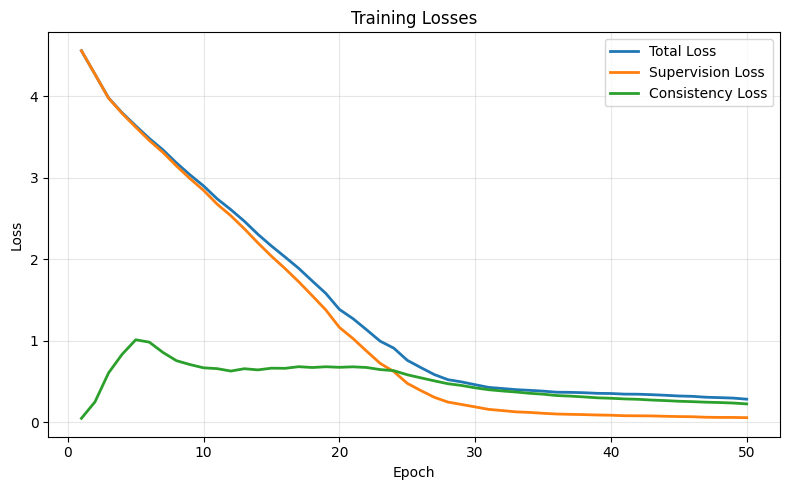

In [26]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, total_losses, label="Total Loss", linewidth=2)
plt.plot(epochs_range, sup_losses, label="Supervision Loss", linewidth=2)
plt.plot(epochs_range, cons_losses, label="Consistency Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
epochs = 200

optimizer = torch.optim.SGD(
    params=student.parameters(),
    lr=0.1,
    momentum=0.9,
    nesterov=True,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs,       
    eta_min=0,
)

total_losses = []
rl_losses = []
sup_losses = []
cons_losses = []

for epoch in range(epochs):
    lambda_entropy = 0.5 - cosine_annealing(epoch, epochs, lambda_min=0.0, lambda_max=0.5)
    losses = train_rlgssl_plus(labeled_loader, unlabeled_loader, student, teacher, optimizer, device, lambda_entropy=lambda_entropy)
    
    total_loss = losses["total_loss"]
    rl_loss = losses["rl_loss"]
    sup_loss = losses["sup_loss"]
    cons_loss = losses["cons_loss"]
    
    if (epoch + 1) % 10 == 0:
        print(f"EPOCH {epoch + 1}: ---> Train Loss: {total_loss:.4f}, RL Loss: {rl_loss:.4f}, Supervision Loss {sup_loss:.4f}, Consistency Loss {cons_loss:.4f}")
        print()

    total_losses.append(total_loss)
    rl_losses.append(rl_loss)
    sup_losses.append(sup_loss)
    cons_losses.append(cons_loss)

385it [00:07, 50.82it/s]
385it [00:07, 53.00it/s]
385it [00:07, 53.09it/s]
385it [00:07, 53.07it/s]
385it [00:07, 53.13it/s]
385it [00:07, 53.12it/s]
385it [00:07, 53.08it/s]
385it [00:07, 49.64it/s]
385it [00:08, 42.94it/s]
385it [00:08, 42.94it/s]


EPOCH 10: ---> Train Loss: 0.2783, RL Loss: 0.0078, Supervision Loss 2.4473, Consistency Loss 0.2581



385it [00:08, 47.95it/s]
385it [00:08, 43.07it/s]
385it [00:08, 43.27it/s]
385it [00:08, 42.85it/s]
385it [00:08, 42.90it/s]
385it [00:08, 43.07it/s]
385it [00:08, 43.15it/s]
385it [00:08, 44.21it/s]
385it [00:08, 47.79it/s]
385it [00:08, 47.66it/s]


EPOCH 20: ---> Train Loss: 0.1364, RL Loss: 0.0079, Supervision Loss 0.7932, Consistency Loss 0.4920



385it [00:07, 52.41it/s]
385it [00:07, 52.62it/s]
385it [00:07, 52.57it/s]
385it [00:07, 52.58it/s]
385it [00:07, 51.41it/s]
385it [00:08, 47.83it/s]
385it [00:08, 47.74it/s]
385it [00:08, 47.81it/s]
385it [00:08, 47.94it/s]
385it [00:08, 48.06it/s]


...

EPOCH 180: ---> Train Loss: 0.0278, RL Loss: 0.0004, Supervision Loss 0.1725, Consistency Loss 0.1015



385it [00:07, 51.99it/s]
385it [00:07, 51.96it/s]
385it [00:07, 48.55it/s]
385it [00:08, 46.70it/s]
385it [00:08, 43.00it/s]
385it [00:08, 43.08it/s]
385it [00:08, 43.08it/s]
385it [00:08, 43.21it/s]
385it [00:08, 47.09it/s]
385it [00:07, 53.20it/s]


EPOCH 190: ---> Train Loss: 0.0380, RL Loss: 0.0003, Supervision Loss 0.2778, Consistency Loss 0.0994



385it [00:07, 53.20it/s]
385it [00:07, 48.46it/s]
385it [00:07, 48.83it/s]
385it [00:07, 48.67it/s]
385it [00:08, 48.08it/s]
385it [00:07, 48.13it/s]
385it [00:08, 48.09it/s]
385it [00:08, 48.07it/s]
385it [00:07, 48.53it/s]
385it [00:07, 48.43it/s]

EPOCH 200: ---> Train Loss: 0.0344, RL Loss: 0.0003, Supervision Loss 0.2385, Consistency Loss 0.1028



In [28]:
test_error, test_acc = evaluate_test_error(student, test_loader, device)
print(f"Test Error: {test_error:.2f}% | Test Accuracy: {test_acc:.2f}%")

Test Error: 84.90% | Test Accuracy: 15.10%


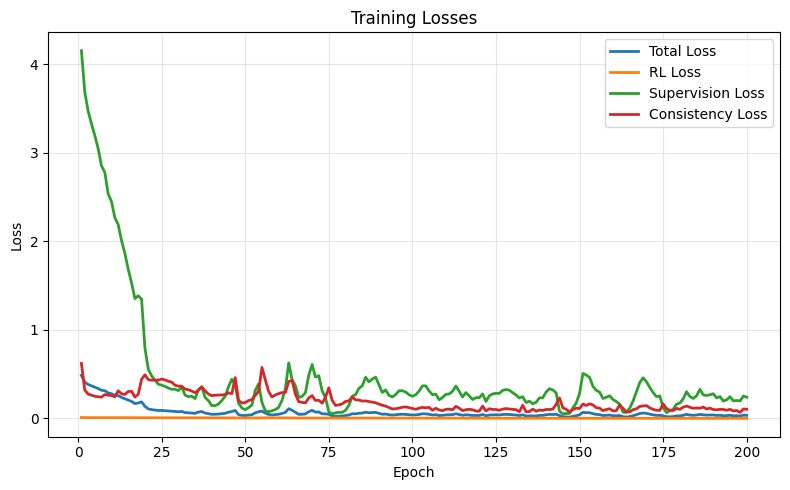

In [29]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, total_losses, label="Total Loss", linewidth=2)
plt.plot(epochs_range, rl_losses, label="RL Loss", linewidth=2)
plt.plot(epochs_range, sup_losses, label="Supervision Loss", linewidth=2)
plt.plot(epochs_range, cons_losses, label="Consistency Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()